# KNN Imputer

### How it works:
Instead of filling NaN with mean/median (which ignores other columns),
KNN Imputer looks at the **K most similar rows** and uses their values to fill the missing one.

**Example:** If Age is missing for a passenger, KNN finds the 5 most similar passengers
(based on Fare, Pclass, etc.) and averages their Age to fill the gap.

This is smarter because similar people tend to have similar ages.

In [2]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer, SimpleImputer

## Step 1 — Understand KNN with a tiny example

In [3]:
# Simple example to understand KNN imputer
# We have 6 people with Age and Fare — one Age is missing

simple_data = pd.DataFrame({
    'Age':  [22, 25, np.nan, 30, 28, 24],
    'Fare': [7.25, 7.50, 7.30, 71.0, 8.0, 7.20]
})

simple_data

,Age,Fare
0,22.0,7.25
1,25.0,7.50
2,NaN,7.30
3,30.0,71.00
4,28.0,8.00
5,24.0,7.20


In [4]:
# Apply KNN Imputer with k=2 (look at 2 nearest neighbours)
# It will find the 2 rows most similar to row 2 (based on Fare=7.30)
# and average their Age values to fill the NaN

knn = KNNImputer(n_neighbors=2)
result = knn.fit_transform(simple_data)

print(pd.DataFrame(result, columns=['Age', 'Fare']))
print("\nThe missing Age was filled with the average Age of the 2 most similar rows")

    Age   Fare
0  22.0   7.25
1  25.0   7.50
2  23.0   7.30
3  30.0  71.00
4  28.0   8.00
5  24.0   7.20

The missing Age was filled with the average Age of the 2 most similar rows


## Step 2 — Load and prepare Titanic data

In [15]:
# Load Titanic dataset — using all useful numerical columns
# KNN imputer only works on numerical columns
df = pd.read_csv('train.csv', usecols=['Age', 'Fare', 'Pclass', 'SibSp', 'Parch', 'Survived'])
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare
0,0,3,22.0,1,0,7.2500
1,1,1,38.0,1,0,71.2833
2,1,3,26.0,0,0,7.9250
3,1,1,35.0,1,0,53.1000
4,0,3,35.0,0,0,8.0500


In [16]:
# Check missing values
df.isnull().mean() * 100

Survived     0.00000
Pclass       0.00000
Age         19.86532
SibSp        0.00000
Parch        0.00000
Fare         0.00000
dtype: float64

In [17]:
# Separate features and target
X = df.drop(columns=['Survived'])
y = df['Survived']

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

## Step 3 — Apply KNN Imputer

In [18]:
# Create KNN Imputer with k=5 (use 5 nearest neighbours)
# Higher k = smoother/more averaged result
# Lower k  = more specific to closest matches
knn_imputer = KNNImputer(n_neighbors=5)

# fit on training data, transform both train and test
# important: always fit on train only to avoid data leakage
X_train_imputed = knn_imputer.fit_transform(X_train)
X_test_imputed  = knn_imputer.transform(X_test)

# convert back to DataFrame so we can view it nicely
X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train.columns)
X_test_imputed  = pd.DataFrame(X_test_imputed,  columns=X_test.columns)

print("Missing values after KNN imputation:")
print(X_train_imputed.isnull().sum())

Missing values after KNN imputation:
Pclass    0
Age       0
SibSp     0
Parch     0
Fare      0
dtype: int64


## Step 4 — Compare KNN vs Mean imputation

In [19]:
# Also apply simple mean imputer for comparison
mean_imputer = SimpleImputer(strategy='mean')

X_train_mean = mean_imputer.fit_transform(X_train)
X_train_mean = pd.DataFrame(X_train_mean, columns=X_train.columns)

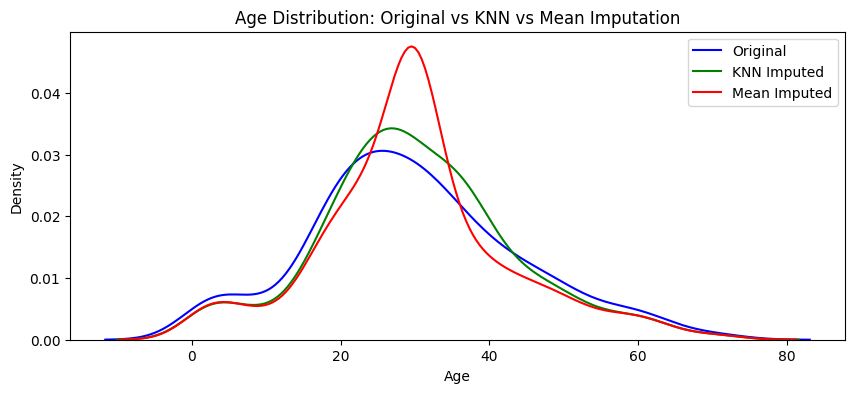

In [20]:
# Plot Age distribution: Original vs KNN vs Mean
# Good imputation = imputed curve should closely follow original curve

plt.figure(figsize=(10, 4))

sns.kdeplot(X_train['Age'].dropna(),      label='Original',       color='blue')
sns.kdeplot(X_train_imputed['Age'],       label='KNN Imputed',    color='green')
sns.kdeplot(X_train_mean['Age'],          label='Mean Imputed',   color='red')

plt.title('Age Distribution: Original vs KNN vs Mean Imputation')
plt.legend()
plt.show()

In [21]:
# Compare variance — how much spread is preserved after imputation?
print(f"Original Age variance : {X_train['Age'].var():.3f}")
print(f"KNN imputed variance  : {X_train_imputed['Age'].var():.3f}")
print(f"Mean imputed variance : {X_train_mean['Age'].var():.3f}")

Original Age variance : 204.350
KNN imputed variance  : 171.998
Mean imputed variance : 161.813


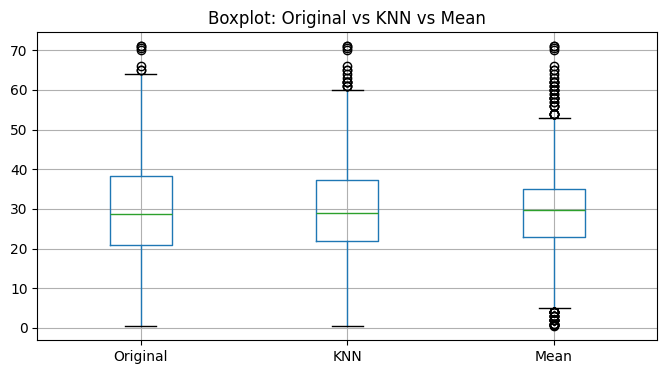

In [22]:
# Boxplot comparison
pd.DataFrame({
    'Original': X_train['Age'],
    'KNN':      X_train_imputed['Age'],
    'Mean':     X_train_mean['Age']
}).boxplot(figsize=(8, 4))

plt.title('Boxplot: Original vs KNN vs Mean')
plt.show()

## Step 5 — Effect of different K values

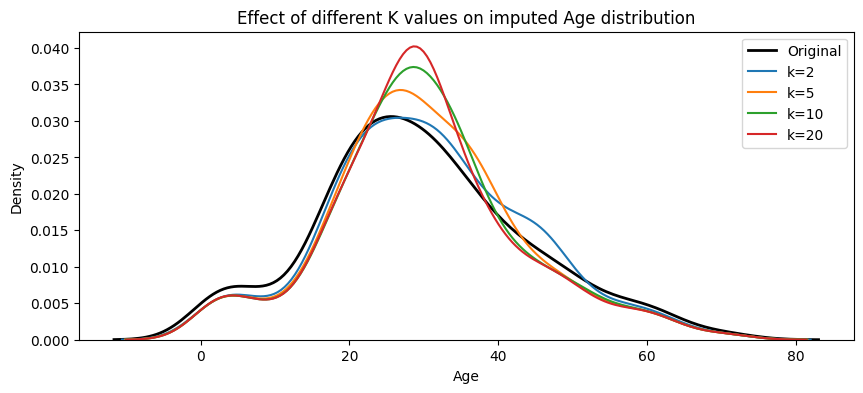

In [23]:
# Try different values of k and see how the imputed distribution changes
# Small k = uses very few neighbours = more specific
# Large k = uses many neighbours = more averaged out (approaches mean imputation)

plt.figure(figsize=(10, 4))
sns.kdeplot(X_train['Age'].dropna(), label='Original', color='black', linewidth=2)

for k in [2, 5, 10, 20]:
    imputer = KNNImputer(n_neighbors=k)
    imputed = imputer.fit_transform(X_train)
    imputed_df = pd.DataFrame(imputed, columns=X_train.columns)
    sns.kdeplot(imputed_df['Age'], label=f'k={k}')

plt.title('Effect of different K values on imputed Age distribution')
plt.legend()
plt.show()

## Summary

| Method | How it fills NaN | Uses other columns? |
|---|---|---|
| Mean Imputer | fixed average value | No |
| Median Imputer | fixed middle value | No |
| Random Sample | random real value | No |
| **KNN Imputer** | **average of K similar rows** | **Yes** |

KNN is the most intelligent imputer because it uses **relationships between columns**
to make a smarter guess — but it is also the **slowest** for large datasets.

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Train model using KNN imputed data
model_knn = LogisticRegression()
model_knn.fit(X_train_imputed, y_train)
knn_accuracy = accuracy_score(y_test, model_knn.predict(X_test_imputed))

# Train model using Mean imputed data
X_test_mean = mean_imputer.transform(X_test)
model_mean = LogisticRegression()
model_mean.fit(X_train_mean, y_train)
mean_accuracy = accuracy_score(y_test, model_mean.predict(X_test_mean))

print(f"Accuracy with Mean Imputation : {mean_accuracy * 100:.2f}%")
print(f"Accuracy with KNN  Imputation : {knn_accuracy * 100:.2f}%")

Accuracy with Mean Imputation : 66.48%
Accuracy with KNN  Imputation : 65.92%


c:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


## Step 6 — Train a model and compare accuracy: KNN vs Mean imputation